# Can daily match information be encoded into immutable VID labels?

This notebook asks whether Reference-ID match information can improve the **labeling itself**, rather than correcting reach after measurement. The goal is to retain the defining advantage of Virtual People (VID) measurement: every impression receives a deterministic label, and every later report is just a unique count over those stored labels.

The short answer is:

- **Yes for aggregate overlap geometry, if days are processed in order and the system keeps a durable model-line-wide identifier-to-VID map.** A provider-estimated cumulative Venn target can be converted into immutable labels while preserving every EDP's reach.
- **Not yet as a complete production design with strict shared-email anchoring.** An email that first appears at another EDP later can conflict with a fallback VID already frozen there. Without reservation, lookahead, or an allowed anchor miss, no online algorithm can guarantee both the email match and exact single-EDP reach.
- **No aggregate-only method can guarantee exact accuracy for every arbitrary time window.** Aggregate counts do not reveal whether an identifier seen today represents a person seen under a different, unlinkable identifier last week.
- **A simple daily hash-pool adjustment is not enough.** It can improve union reach while introducing same-publisher collisions, stable-ID fragmentation, or campaign-order dependence.
- **The most promising direction is a sequential, coordinated rank allocator driven by a provider-supplied cumulative calibration rule.** The aggregate Venn projection is feasible; direct-anchor reservation and calibration-transfer guardrails are the remaining gating research questions.

“Reference ID” means the approved single join key—normally normalized email, with an EDP-proprietary fallback—hashed into the common 5-billion-value space. Reference-ID matching and calibration occur inside the approved TEE workload.

In [1]:
from pathlib import Path
import csv
import json
import sys
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, Markdown, display


def find_project_root():
    for candidate in (Path.cwd(), Path.cwd().parent):
        if (candidate / "src" / "reference_calibration").exists():
            return candidate.resolve()
    raise RuntimeError("Run this notebook from the repository root or notebooks/.")


def markdown_table(rows, columns):
    header = "| " + " | ".join(label for _, label in columns) + " |"
    separator = "|" + "|".join("---" for _ in columns) + "|"
    body = [
        "| " + " | ".join(str(row[key]).replace("|", "/") for key, _ in columns) + " |"
        for row in rows
    ]
    return "\n".join([header, separator, *body])


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "daily_labeling_final"
VENN_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "full_venn_proof_final"
CALIBRATED_VENN_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "calibrated_venn_pairwise_half5"
DIRECT_VENN_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "calibrated_venn_direct_pair_half5"
ALL_MODELS_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "calibrated_venn_labeling_final"
SOLVER_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "temporal_solver_benchmark_union_guard"
IDENTITY_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "online_identity_constraints"
REGULARIZATION_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "online_regularization_sweep"

RUN_EXPERIMENT = False
if RUN_EXPERIMENT:
    from reference_calibration.daily_labeling import run_daily_labeling_experiment
    run_daily_labeling_experiment(OUTPUT_DIR, profile="full")

summary = json.loads((OUTPUT_DIR / "daily_labeling_summary.json").read_text())
with (OUTPUT_DIR / "daily_labeling_metrics.csv").open() as stream:
    metrics = list(csv.DictReader(stream))
with (OUTPUT_DIR / "daily_dials.csv").open() as stream:
    dials = list(csv.DictReader(stream))
with (OUTPUT_DIR / "cross_campaign_metrics.csv").open() as stream:
    portfolio = list(csv.DictReader(stream))
venn_summary = json.loads((VENN_OUTPUT_DIR / "full_venn_summary.json").read_text())
with (VENN_OUTPUT_DIR / "full_venn_metrics.csv").open() as stream:
    venn_metrics = list(csv.DictReader(stream))
calibrated_venn_summary = json.loads(
    (CALIBRATED_VENN_OUTPUT_DIR / "calibrated_venn_summary.json").read_text()
)
direct_venn_summary = json.loads(
    (DIRECT_VENN_OUTPUT_DIR / "calibrated_venn_summary.json").read_text()
)
all_models_summary = json.loads(
    (ALL_MODELS_OUTPUT_DIR / "calibrated_venn_summary.json").read_text()
)
with (CALIBRATED_VENN_OUTPUT_DIR / "calibrated_venn_metrics.csv").open() as stream:
    calibrated_venn_metrics = list(csv.DictReader(stream))
solver_summary = json.loads((SOLVER_OUTPUT_DIR / "temporal_solver_summary.json").read_text())
identity_summary = json.loads(
    (IDENTITY_OUTPUT_DIR / "online_identity_constraints.json").read_text()
)
regularization_summary = json.loads(
    (REGULARIZATION_OUTPUT_DIR / "online_regularization_summary.json").read_text()
)

print(f"Synthetic users: {summary['configuration']['n_users']:,}")
print(f"EDPs: {summary['configuration']['n_edps']}")
print(f"Weeks: {summary['configuration']['n_weeks']}")
print(f"Training campaigns: {summary['training_campaign_count']}")
print(f"Independent evaluation campaigns: {summary['evaluation_campaign_count']}")

Synthetic users: 18,000
EDPs: 10
Weeks: 13
Training campaigns: 26
Independent evaluation campaigns: 35


## 1. The problem in plain language

Post-measurement calibration can produce a better number for one report, but it weakens the meaning of the underlying impression labels. A report for weeks 1–3 and a later report for weeks 1–12 may need separate corrections. A two-EDP report and a five-EDP report may also be corrected separately. Reconciliation can reduce contradictions, but the corrected values are no longer simply the number of distinct people represented by the impressions.

Label-time calibration tries to move the correction earlier:

1. observe the campaign's match behavior for a day or cumulatively through that day;
2. choose a pool configuration that creates the desired amount of cross-EDP VID overlap;
3. assign final VIDs to that day's impressions; and
4. never change those labels again.

Once every event has one immutable VID, a report over any set of events is a set cardinality. Therefore a larger event set cannot have smaller reach, overlapping reports obey ordinary set arithmetic, and re-running the same report does not require retrieving its old result.

That consistency guarantee does **not** prove accuracy. A labeler can be perfectly self-consistent and still map one real person to several VIDs or map several people to one VID.

## 2. What the current implementation already provides

The WFA code has most of the mechanical primitives, but not the complete adaptive design:

| Existing primitive | Current behavior | Relevance here |
|---|---|---|
| Population pool | Hashes the acting fingerprint into fixed VID ranges. Collisions are allowed. | A smaller shared pool creates more cross-EDP overlap, but also more same-EDP collisions unless compensated. |
| Weighted consistent branch | Chooses among fixed branches with weighted rendezvous-style hashing. Small weight changes move relatively few identifiers. | Useful for a quantized daily overlap dial, but “few moves” is not “no moves.” |
| Ranked population pool | Uses a stored local rank and a Feistel permutation for collision-free assignment within a pool. | The natural basis for an ordered 1:1 design. |
| Memoized rank pipeline | Routes fingerprints to subpools, maintains rank maps, and attaches ranks before final labeling. | It already supplies a multi-pass processing shape that could host a daily calibration manifest. |
| Date-based model selection | Selects a model release deterministically from the event date and identifier. | Supports frozen date-specific configuration, although cross-date identity stability still has to be designed. |

One important change would be required. The current memoized stack can store a fingerprint in more than one subpool. If later events route that fingerprint to another subpool, it can receive another VID. The strict-stability design evaluated here instead assumes one canonical model-line mapping:

`stable identifier → chosen pool + rank/VID`

Once present, that mapping overrides later routing suggestions.

## 3. The proposed daily workflow

Same-day match information cannot be used by independent EDP labelers without coordination. It requires a daily barrier and two logical passes:

1. Each EDP reads the day's raw impressions inside its TEE and produces encrypted aggregate Reference-ID counts and the set of newly seen labeling identifiers.
2. An approved TEE workload combines the EDP aggregates with the campaign-to-date state.
3. The model provider's frozen rule converts objective, audience strategy, scale, email availability, and pairwise or higher-order Reference-ID matches into pool probabilities or allocation quotas.
4. The workload freezes a date/model-line calibration manifest.
5. EDPs route and rank only newly seen identifiers under that manifest. Existing identifiers reuse their canonical stored VID.
6. Final impressions are labeled and become immutable.

Days must be finalized in event-time order. A watermark defines when a day is ready. Late data uses the already-frozen manifest for its event date; it does not reopen earlier assignments. Campaign-to-date match statistics can be retained inside the TEE and updated after each finalized day.

Using the previous day's manifest avoids the barrier but adds one day of lag. Buffering several days or the full flight produces a more stable estimate but delays final labels and early reports.

## 4. A limit no pool design can remove

Suppose EDP A reaches two people on day 1 using proprietary IDs. On day 2, EDP B also supplies two proprietary IDs, and no email is available.

- In one possible world, B reached the same two people. True union reach is 2.
- In another possible world, B reached two different people. True union reach is 4.

The labeler receives identical identifiers and aggregate counts in both worlds. It must therefore make the same deterministic assignment in both worlds, so it must be wrong in at least one.

The same ambiguity appears across campaigns and arbitrary time windows. Exact guarantees require at least one of:

- a real link between the identifiers;
- enough future information to delay the original assignment;
- a richer output that preserves several candidate identities; or
- acceptance that some report shapes have an accuracy bound rather than exact recovery.

This is why the experiments report both **logical consistency** and **accuracy**.

## 5. Pool and labeling designs tested

The fixed-marginal idea is simplest with two EDPs. If their cumulative reaches are (n_A) and (n_B), and the provider rule estimates an overlap of (I), construct three logical pools:

- A-only: (n_A-I) active slots;
- B-only: (n_B-I) active slots; and
- shared A∩B: (I) active slots.

Changing (I) changes only how the two fixed-size EDP sets overlap. It does not change either EDP's reach. With more EDPs, the same idea becomes an allocation over exclusive subset cells. The implementation can estimate only pairwise and a few structural parameters, then derive the larger cell table inside the TEE; it does not need 1,023 independently fitted curves.

For example, if A has reach 100 and B has reach 80, an estimated overlap of 30 produces 70 A-only slots, 50 B-only slots, and 30 shared slots: union reach is 150. If later evidence supports overlap 50, the construction becomes 50 A-only, 30 B-only, and 50 shared: union reach is 130. A remains 100 and B remains 80 in both cases. At ten EDPs there are 45 pair relationships; higher-order sharing must still be generated coherently from those pair targets or from a small number of additional structural terms.

This is different from shrinking a hash pool. Shrinking a hash pool can make two unrelated IDs from the **same** EDP collide, which damages that EDP's reach. A fixed-marginal allocator first reserves exactly as many distinct VID slots as each EDP needs, then changes which of those slots are shared by two or more EDPs. Shared-email matches remain direct anchors; the adjustable part is principally the placement of proprietary fallback IDs.

Three implementation conditions matter:

1. “Fixed” must mean the realized per-EDP assignment is preserved—not merely that a hash range has the same capacity. A collision-free rank map, or an unchanged marginal hash distribution with separately measured collision behavior, is needed.
2. Directly shared email keys should be placed before synthetic fallback sharing for the day.
3. A shared email can first appear at another EDP later. If its canonical VID was already occupied there by a finalized fallback assignment, exact anchoring and exact single-EDP reach cannot both be preserved. A production design therefore needs an anchor-reservation policy, a short finalization buffer, or an explicitly modeled collision allowance. This is a real online constraint, not a calibration-detail problem.

| Design | Intuition | Main expected benefit | Main risk |
|---|---|---|---|
| Fixed model-line pool | Use one setting learned from broad calibration campaigns. | Simple, stable, and compatible with today's model shape. | Cannot react to narrow or unusually overlapping campaigns. |
| Same-day adaptive hash pool | Higher daily matching sends more fallback IDs into a small shared pool. | Reacts immediately. | Noisy daily estimates and the same ID can move across days. |
| Cumulative adaptive hash pool | Use campaign-to-date matching instead of one day. | More stable signal. | Still changes a stateless ID's mapping when the dial changes. |
| Quantized/hysteretic pool | Smooth the cumulative estimate and change it only in coarse steps. | Reduces mapping churn. | Retains some churn and responds slowly. |
| Stored first-seen map | The current dial applies only when an ID first appears; later events reuse its VID. | Zero within-EDP ID churn. | Early data permanently determines many assignments; ordinary hash collisions can reduce marginal reach. |
| Collision-resolved overlap pool | Store first-seen mappings and move same-EDP collisions to unused slots. | Keeps each EDP's reach essentially exact. | Needs its own calibration and a central view of occupied slots. |
| Fixed-marginal overlap atlas | Hold each EDP's VID-set size fixed and change only how those sets overlap. | Directly implements the desired idea without sacrificing single-EDP reach or population bounds. | A scalar total-overlap target does not determine accurate EDP-subset geometry. |
| Pair-targeted fixed-marginal atlas | Keep the same fixed EDP sets, but use calibrated Reference-ID pairs to decide which EDPs should share slots. | Uses 45 interpretable pair relationships plus one shared log-size slope—46 provider-fitted parameters at ten EDPs—while preserving every single-EDP reach. | Pairs do not uniquely determine three-way and higher-order overlap; the online greedy placement can also lock in early choices. |
| Ranked overlap lattice | Use private, pair-specific, and nested higher-order ranked lanes. | Compact structural representation: 64 lanes at ten EDPs. | A naive routing rule cannot reliably turn one scalar dial into the right full overlap geometry. |
| Three-day or full-flight buffer | Estimate once, then label all buffered events with one frozen setting. | Stable mapping and better signal. | Delayed labels; a full-flight buffer cannot support early final reports. |
| Online union allocator | Create or reuse synthetic slots to hit one cumulative total-union target exactly. | Scales to ten EDPs and preserves marginals. | Does not determine accurate pairwise or subset unions. |
| Online Venn allocator | Target every cumulative overlap cell jointly. | Exact cumulative subset unions in the oracle experiment. | Exponential state and aggregate timing ambiguity for arbitrary subwindows. |
| Real-person identity oracle | Give every real person one VID. | Exact for every report. | Requires the prohibited identity graph; included only as an accuracy ceiling. |

## 6. Synthetic experiment

The full run uses 18,000 synthetic people, ten EDPs, thirteen bursty weeks, separate training and evaluation campaigns, and the existing scenario generator. Base email availability ranges from 10% to 95% by EDP and conditional agreement ranges from 52% to 72%. The evaluation includes broad awareness, traffic, engagement, leads, sales prospecting, website and app retargeting, customer lists, catalog retargeting, lookalikes, audience expansion, unrelated niches, mixed-funnel reports, controlled linkage shifts, and three temporal stress cases.

Reports include:

- weeks 1–3 followed later by weeks 1–12;
- weeks 5–12 and weeks 7–13;
- noncontiguous weeks;
- two-, five-, and ten-EDP subsets; and
- full-flight reports.

The provider-side example model is intentionally modest: a ridge-regularized function predicts the pool dial from campaign context, scale, per-EDP email availability, and aggregate pairwise Reference-ID matching. Whole campaigns are separated between fitting and evaluation. The synthetic truth is used only for scoring and for explicitly labeled oracle methods.

In [2]:
method_labels = {
    "fixed_model_line_pool": "Fixed model-line pool",
    "same_day_adaptive_pool": "Same-day adaptive",
    "cumulative_adaptive_pool": "Cumulative adaptive",
    "quantized_hysteresis_pool": "Quantized cumulative",
    "sticky_first_seen_pool": "Stored first-seen map",
    "ordered_collision_resolved_overlap_pool": "Collision-resolved stored map",
    "fixed_marginal_overlap_atlas": "Fixed-marginal fallback allocator",
    "pair_targeted_fixed_marginal_atlas": "Pair-targeted fixed-marginal fallback allocator",
    "ordered_memoized_rank_lattice": "64-lane ranked lattice",
    "cohort_3_week_rank_lattice": "3-week cohort lattice",
    "three_day_buffer_then_freeze": "3-day buffer then freeze",
    "full_flight_buffer_then_freeze": "Full-flight buffer then freeze",
    "oracle_online_union_oldest": "Oracle cumulative-union allocator",
    "oracle_online_venn_recent": "Oracle cumulative-Venn allocator",
    "forbidden_person_identity_oracle": "Forbidden identity oracle",
}

headline = []
for method, label in method_labels.items():
    result = summary["methods"][method]
    headline.append({
        "method": label,
        "mean": f"{result['union_error']['mean']:.1%}",
        "p90": f"{result['union_error']['p90']:.1%}",
        "marginal": f"{result['marginal_reach_error']['mean']:.1%}",
        "id_churn": f"{result['stable_key_fragmentation']:.1%}",
        "email_split": f"{result['cross_edp_email_fragmentation']:.1%}",
        "population": f"{result['population_bound_excess']['max']:.1%}",
        "structure": (
            "45 pairs + 1 slope"
            if method == "pair_targeted_fixed_marginal_atlas"
            else f"{result['pool_count']} pools"
        ),
        "violations": result["consistency"]["nested_report_violations"],
    })
display(Markdown(markdown_table(
    headline,
    [
        ("method", "Method"),
        ("mean", "Mean union error"),
        ("p90", "p90 union error"),
        ("marginal", "Mean per-EDP reach error"),
        ("id_churn", "Within-EDP ID churn"),
        ("email_split", "Shared-email fragmentation"),
        ("population", "Worst population-bound excess"),
        ("structure", "Structural complexity"),
        ("violations", "Nested-report violations"),
    ],
)))

| Method | Mean union error | p90 union error | Mean per-EDP reach error | Within-EDP ID churn | Shared-email fragmentation | Worst population-bound excess | Structural complexity | Nested-report violations |
|---|---|---|---|---|---|---|---|---|
| Fixed model-line pool | 25.1% | 70.7% | 2.4% | 0.0% | 0.0% | 0.0% | 2 pools | 0 |
| Same-day adaptive | 11.7% | 30.0% | 6.4% | 1.7% | 0.0% | 0.0% | 2 pools | 0 |
| Cumulative adaptive | 9.8% | 23.7% | 7.3% | 2.8% | 0.0% | 0.0% | 2 pools | 0 |
| Quantized cumulative | 11.2% | 29.1% | 6.5% | 2.8% | 0.0% | 0.0% | 2 pools | 0 |
| Stored first-seen map | 9.8% | 23.7% | 7.4% | 0.0% | 0.0% | 0.0% | 2 pools | 0 |
| Collision-resolved stored map | 9.2% | 21.9% | 0.0% | 0.0% | 0.0% | 37.2% | 2 pools | 0 |
| Fixed-marginal fallback allocator | 16.0% | 33.8% | 0.0% | 0.0% | 100.0% | 0.0% | 1 pools | 0 |
| Pair-targeted fixed-marginal fallback allocator | 10.4% | 22.8% | 0.0% | 0.0% | 100.0% | 0.0% | 45 pairs + 1 slope | 0 |
| 64-lane ranked lattice | 17.9% | 42.8% | 0.0% | 0.0% | 0.0% | 56.3% | 64 pools | 0 |
| 3-week cohort lattice | 21.7% | 53.8% | 0.0% | 0.0% | 0.0% | 56.3% | 280 pools | 0 |
| 3-day buffer then freeze | 11.9% | 29.5% | 6.3% | 0.0% | 0.0% | 0.0% | 2 pools | 0 |
| Full-flight buffer then freeze | 8.7% | 18.8% | 8.4% | 0.0% | 0.0% | 0.0% | 2 pools | 0 |
| Oracle cumulative-union allocator | 7.0% | 18.1% | 0.0% | 0.0% | 100.0% | 0.0% | 1 pools | 0 |
| Oracle cumulative-Venn allocator | 1.5% | 6.0% | 0.0% | 0.0% | 99.3% | 0.0% | 31 pools | 0 |
| Forbidden identity oracle | 0.0% | 0.0% | 0.0% | 0.0% | 0.0% | 0.0% | 1 pools | 0 |

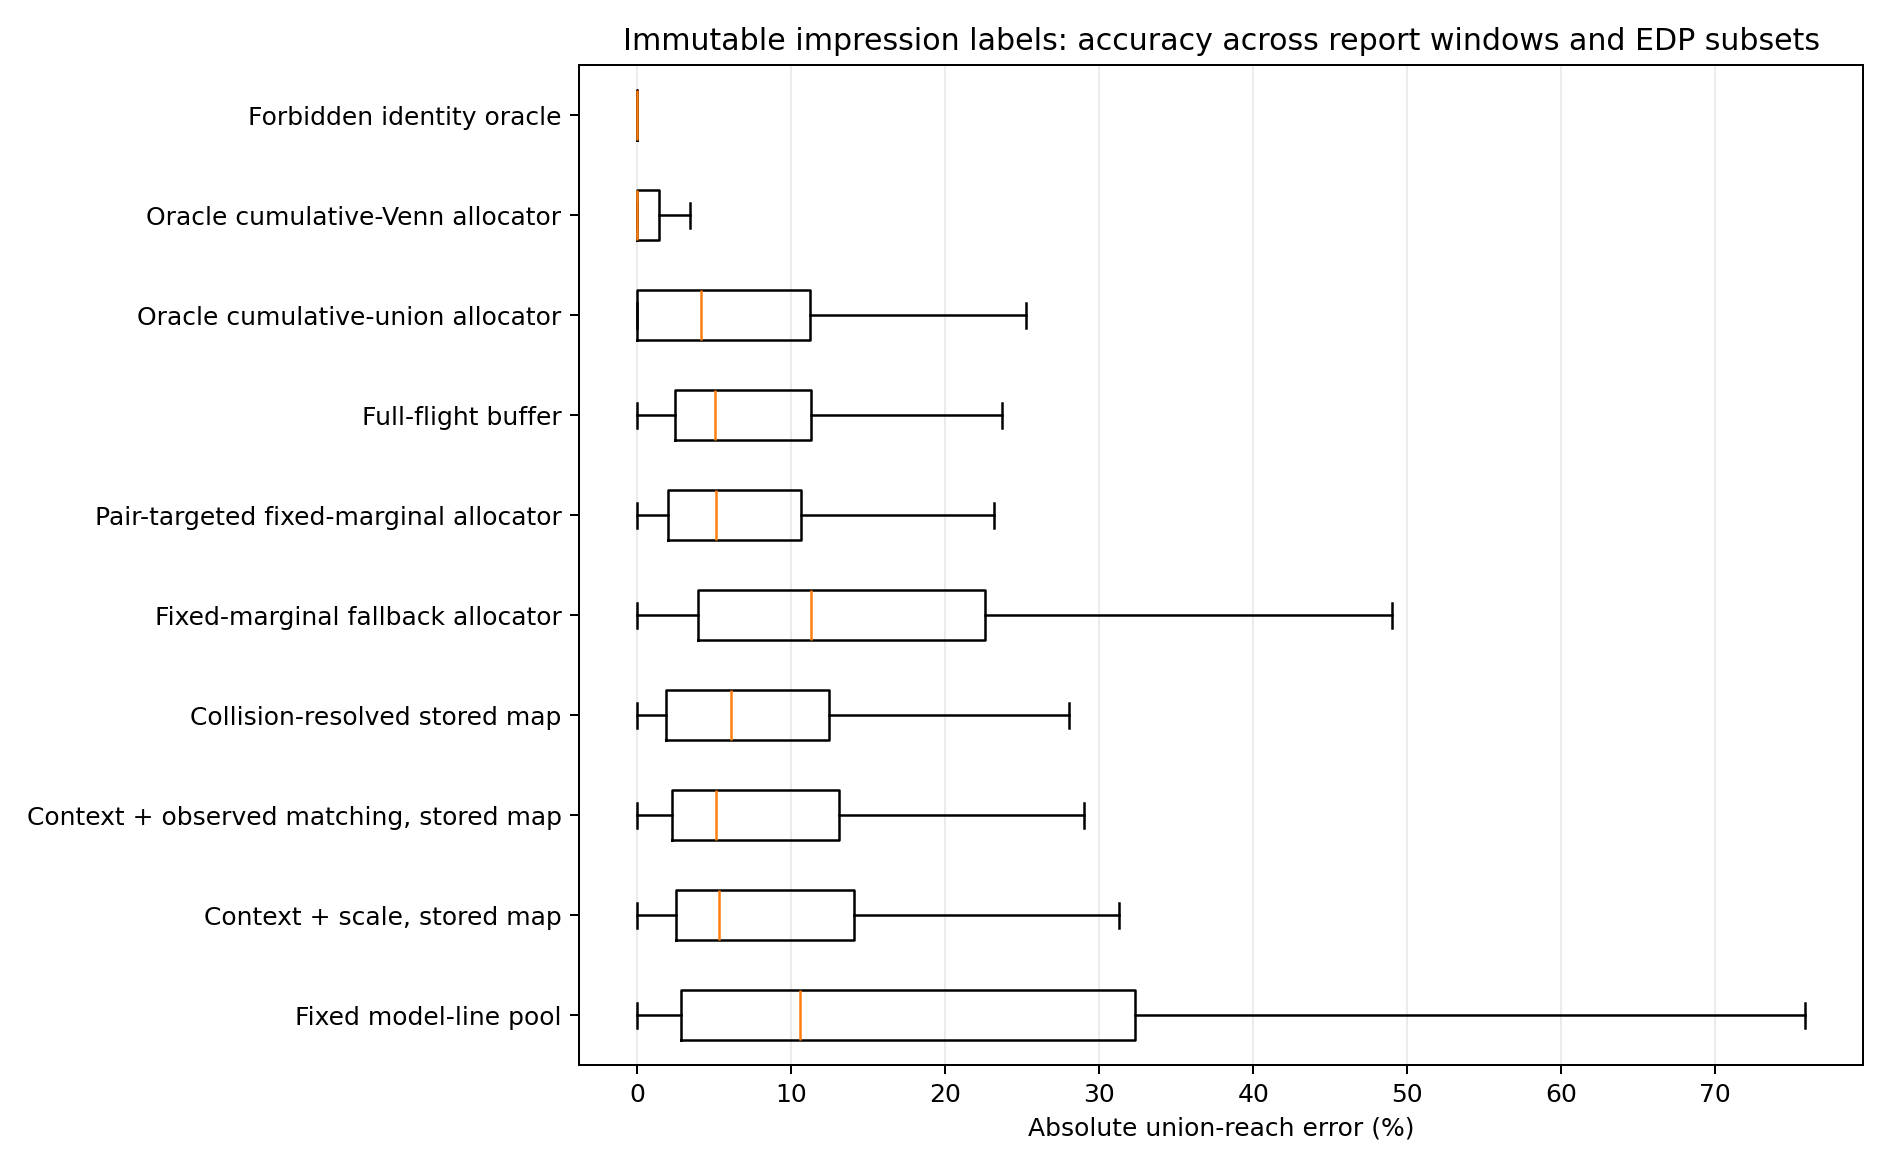

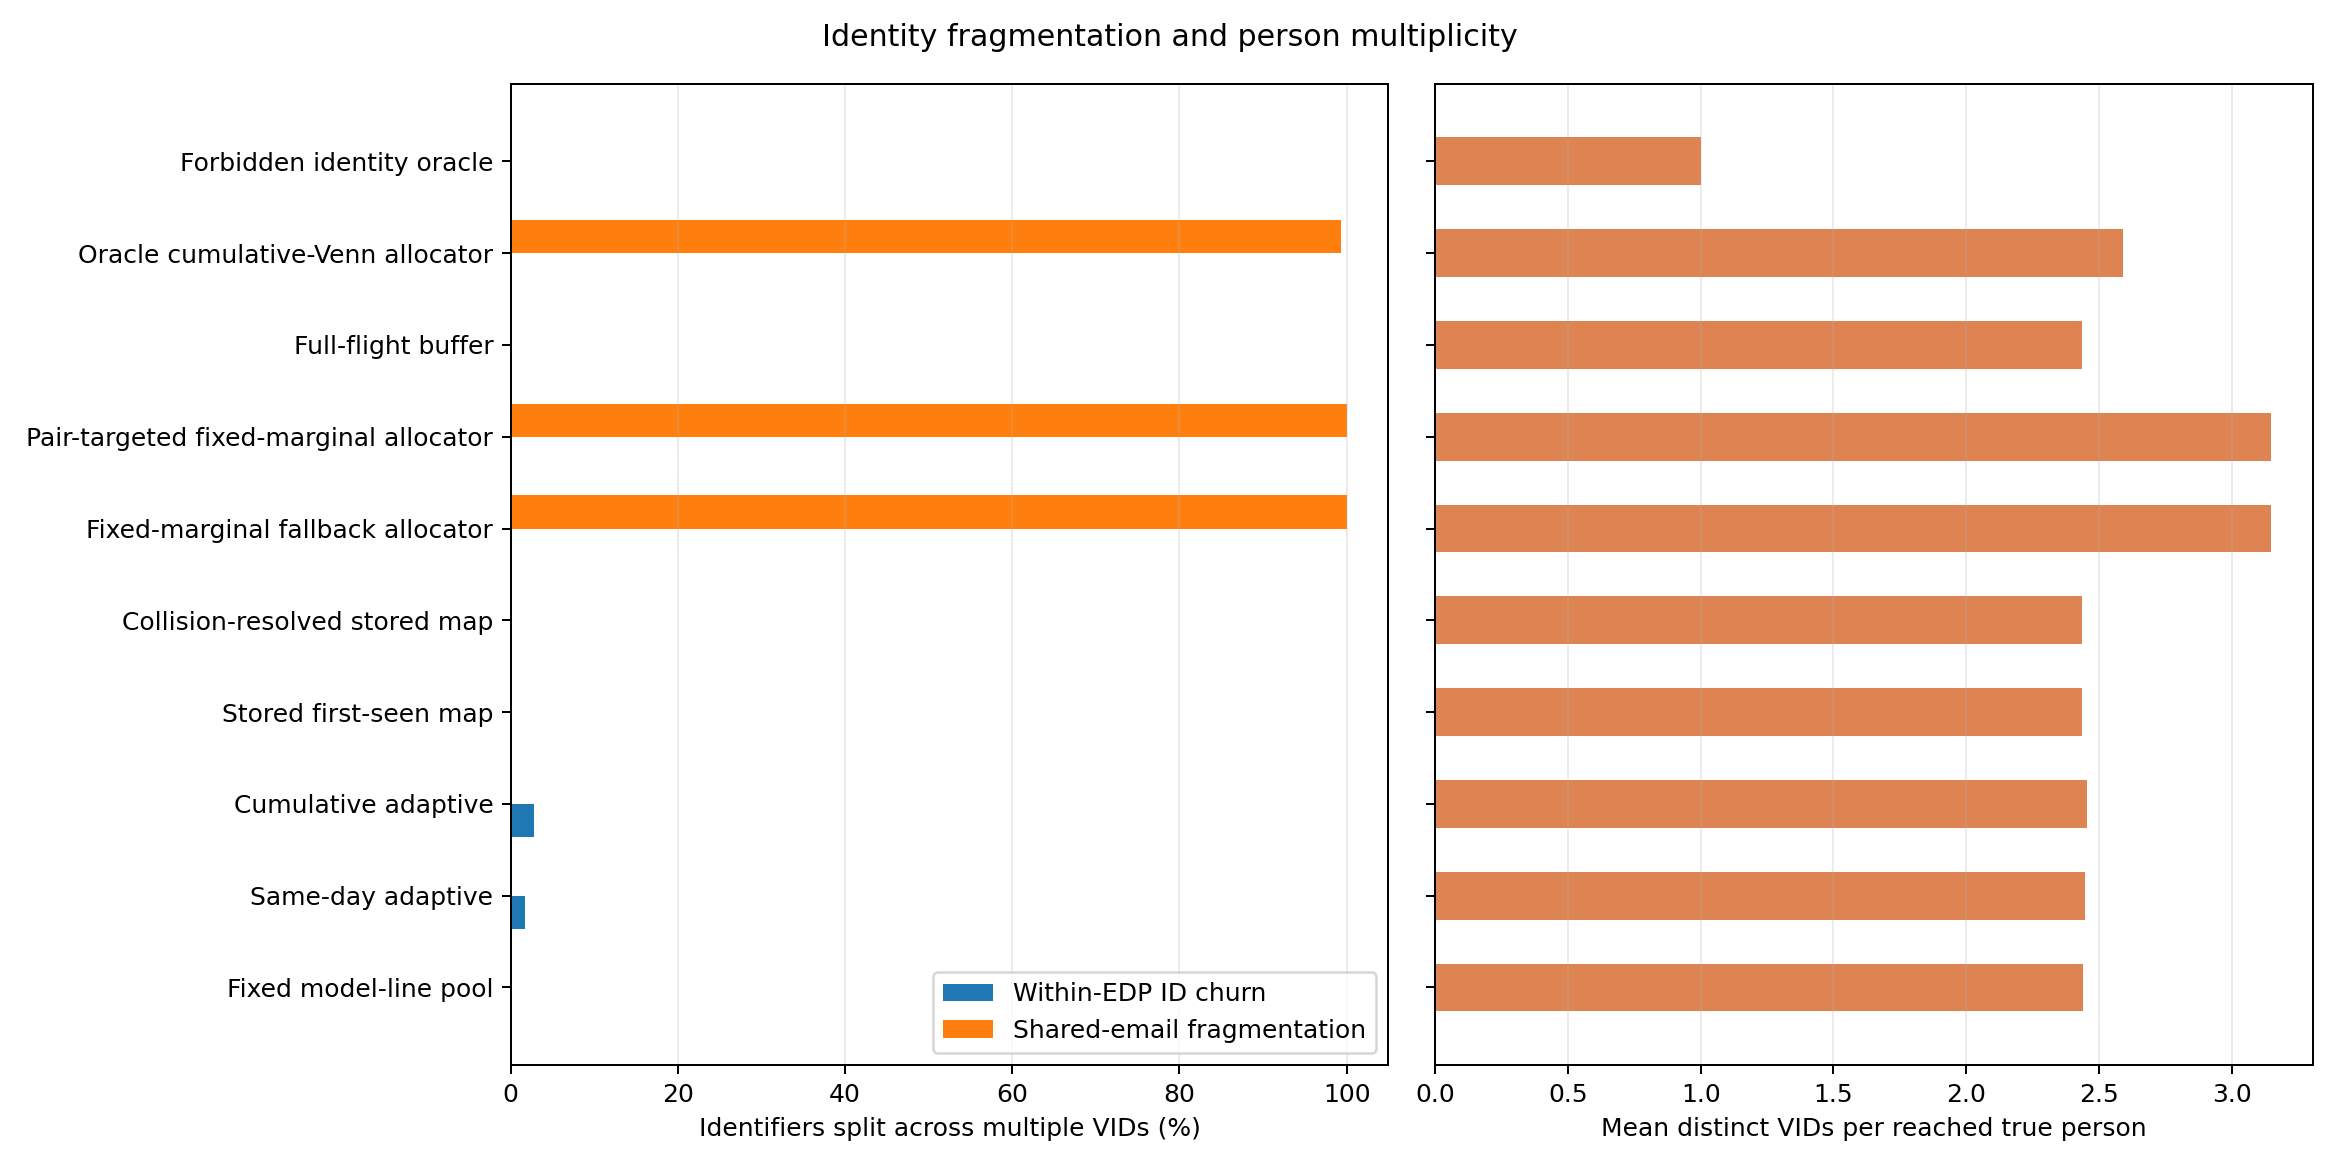

In [3]:
display(Image(filename=str(OUTPUT_DIR / "daily_labeling_error.png")))
display(Image(filename=str(OUTPUT_DIR / "daily_labeling_fragmentation.png")))

In [4]:
intersection_methods = {
    "fixed_model_line_pool": "Fixed model-line pool",
    "ordered_collision_resolved_overlap_pool": "Collision-resolved stored map",
    "fixed_marginal_overlap_atlas": "Fixed-marginal fallback allocator",
    "pair_targeted_fixed_marginal_atlas": "Pair-targeted fixed-marginal fallback allocator",
    "ordered_memoized_rank_lattice": "64-lane ranked lattice",
    "oracle_online_venn_recent": "Oracle cumulative-Venn allocator",
    "forbidden_person_identity_oracle": "Forbidden identity oracle",
}
rows = []
for method, label in intersection_methods.items():
    selected = [row for row in metrics if row["method"] == method]
    rows.append({
        "method": label,
        "pair": f"{np.median([float(row['pair_intersection_error']) for row in selected]):.1%}",
        "three": f"{np.median([float(row['three_way_intersection_error']) for row in selected]):.1%}",
        "four": f"{np.median([float(row['four_plus_intersection_error']) for row in selected]):.1%}",
    })
display(Markdown(markdown_table(
    rows,
    [
        ("method", "Method"),
        ("pair", "Median pair-intersection error"),
        ("three", "Median three-way error"),
        ("four", "Median four-way-and-higher error"),
    ],
)))

| Method | Median pair-intersection error | Median three-way error | Median four-way-and-higher error |
|---|---|---|---|
| Fixed model-line pool | 41.9% | 52.0% | 60.8% |
| Collision-resolved stored map | 19.5% | 38.8% | 73.1% |
| Fixed-marginal fallback allocator | 68.5% | 76.5% | 144.6% |
| Pair-targeted fixed-marginal fallback allocator | 36.6% | 62.5% | 82.1% |
| 64-lane ranked lattice | 28.9% | 44.2% | 58.3% |
| Oracle cumulative-Venn allocator | 0.0% | 0.0% | 0.0% |
| Forbidden identity oracle | 0.0% | 0.0% | 0.0% |

### Reading the headline results

All methods using stored impression labels have zero logical report contradictions. That is expected: cardinality over immutable labels is inherently consistent.

The fixed-marginal prototypes deliberately treat all inputs as EDP-local fallback IDs so the experiment can isolate the synthetic overlap allocator. That is why their “shared-email fragmentation” column is 100%. It is not a proposed production behavior: a deployable version must place directly shared email anchors first, then allocate only the residual proprietary-ID reach. The anchor-reservation issue described above remains to be tested.

The difficult tradeoff is elsewhere:

- A stateless daily pool can improve union reach but split one stable identifier across VIDs when its daily setting changes.
- Remembering the first assignment removes that churn, but later evidence can affect only new identifiers.
- A small collision pool may improve cross-EDP overlap partly by collapsing identifiers within an EDP. The collision-resolved variant removes that artifact, so its calibration must be refit for the new encoder.
- Keeping pool sizes fixed and changing only their overlap is the correct structural direction. The tested fixed-marginal atlas proves it can preserve single-EDP reach and the population bound. Its remaining error comes from predicting only one total-overlap dial and then heuristically choosing the EDP geometry. The pairwise and higher-order table makes that limitation visible.
- The pair-targeted atlas is a closer implementation of the proposed design: at ten EDPs one validated rule sets the cumulative total, while 45 learned pair relationships decide which EDP pools should share the slots. Its higher-order results show how much information is still missing when only pairs are targeted.
- Intersection errors are reported as the median across reports. Tiny true intersections can have very large percentage errors, so mean relative error is dominated by a small number of sparse higher-order cells.
- The compact ranked lattice preserves per-EDP reach, but a simple scalar dial does not specify enough geometry for all pairs and higher-order intersections.
- The oracle allocators demonstrate that ordered immutable assignment is not itself the blocker. The missing piece is a sufficiently accurate, feasible target for the allocator.

## 7. Cumulative prefixes versus arbitrary windows

The online union oracle is told only the correct cumulative ten-EDP total. It makes that total exact at every prefix, but it does not know which EDP subsets should share each slot. The online Venn oracle is told all cumulative overlap cells for five EDPs, so every cumulative subset is exact.

Neither oracle is told the hidden identity correspondence across time. When it must decide which old slot receives a newly seen identifier, “prefer recent” and “prefer old” are both plausible. The results below show that no one heuristic wins for every window shape.

In [5]:
oracle_methods = {
    "oracle_online_union_recent": "Union target / prefer recent",
    "oracle_online_union_oldest": "Union target / prefer old",
    "oracle_online_venn_recent": "Venn target / prefer recent",
    "oracle_online_venn_oldest": "Venn target / prefer old",
}
rows = []
for method, label in oracle_methods.items():
    selected = [row for row in metrics if row["method"] == method]
    for report_type in ("prefix", "interval", "noncontiguous"):
        values = [float(row["union_relative_error"]) for row in selected if row["report_type"] == report_type]
        if not values:
            continue
        rows.append({
            "method": label,
            "report_type": report_type,
            "mean": f"{np.mean(values):.1%}",
            "p90": f"{np.quantile(values, .9):.1%}",
        })
display(Markdown(markdown_table(
    rows,
    [("method", "Oracle target"), ("report_type", "Report shape"), ("mean", "Mean error"), ("p90", "p90")],
)))

| Oracle target | Report shape | Mean error | p90 |
|---|---|---|---|
| Union target / prefer recent | prefix | 5.9% | 18.1% |
| Union target / prefer recent | interval | 20.3% | 32.3% |
| Union target / prefer recent | noncontiguous | 13.2% | 24.6% |
| Union target / prefer old | prefix | 5.3% | 17.2% |
| Union target / prefer old | interval | 11.8% | 22.8% |
| Union target / prefer old | noncontiguous | 11.1% | 18.5% |
| Venn target / prefer recent | prefix | 0.0% | 0.0% |
| Venn target / prefer recent | interval | 2.6% | 5.7% |
| Venn target / prefer recent | noncontiguous | 6.7% | 9.4% |
| Venn target / prefer old | prefix | 0.0% | 0.0% |
| Venn target / prefer old | interval | 6.7% | 12.7% |
| Venn target / prefer old | noncontiguous | 2.9% | 5.7% |

The result is useful even though the targets are oracles:

- Knowing only the full-roster union is insufficient for reports containing fewer EDPs.
- Knowing the complete cumulative five-EDP Venn diagram is sufficient for every cumulative prefix and EDP subset.
- Arbitrary middle and noncontiguous windows still have error because the cumulative cells do not say *when* the synthetic matches should occur.
- Adding first-seen-time cohorts can reduce one class of window error but can worsen another. Exact arbitrary-window behavior would require arrival-time overlap cells, a genuine identity link, or delaying assignment until the relevant future is known.

## 7A. What if the complete Venn diagram is available for all ten EDPs?

For ten EDPs, a complete cumulative Venn diagram contains 1,023 nonempty exact cells. It specifies how many people have been reached by exactly each EDP combination. Equivalently, the workload may receive every inclusive pairwise through ten-way intersection and recover the exact cells by inclusion–exclusion, provided the inputs are jointly valid.

### Cumulative-prefix guarantee

Assume the full cumulative Venn table at every checkpoint comes from one real underlying population. At checkpoint (t-1), each stored VID has a current EDP-membership mask (S). At checkpoint (t), that person can remain in (S) or move only to a superset (T) as additional EDPs reach them. Newly reached people enter from the empty mask.

Construct a flow network with an edge (S → T) whenever (S ⊆ T). The prior cell counts plus the required number of new people are supplies; the new Venn cells are demands. The real population itself proves that a feasible flow exists. Because this is an integer network-flow problem, it has an integer solution. Assign rank-ordered new EDP identifiers along that flow and freeze the resulting VIDs. By induction, every cumulative Venn cell is exact at every checkpoint.

Therefore every cumulative report over **any subset of the ten EDPs** is exact—not merely the full ten-EDP union. This is a genuine guarantee, conditional on receiving valid full cumulative Venn tables.

| Information supplied | Mean: all reports | Cumulative prefixes | Middle intervals | Noncontiguous weeks | Worst report |
|---|---|---|---|---|---|
| Full daily Venn only | 89.7% | 104.1% | 87.5% | 54.0% | 438.4% |
| Full cumulative Venn / prefer recent | 1.6% | 0.0% | 2.5% | 4.5% | 10.8% |
| Full cumulative Venn / prefer old | 2.1% | 0.0% | 6.2% | 2.1% | 15.6% |

Exact-cell audits: {'daily_full_venn_max_cell_difference': 0, 'cumulative_full_venn_recent_max_prefix_cell_difference': 0, 'cumulative_full_venn_oldest_max_prefix_cell_difference': 0}


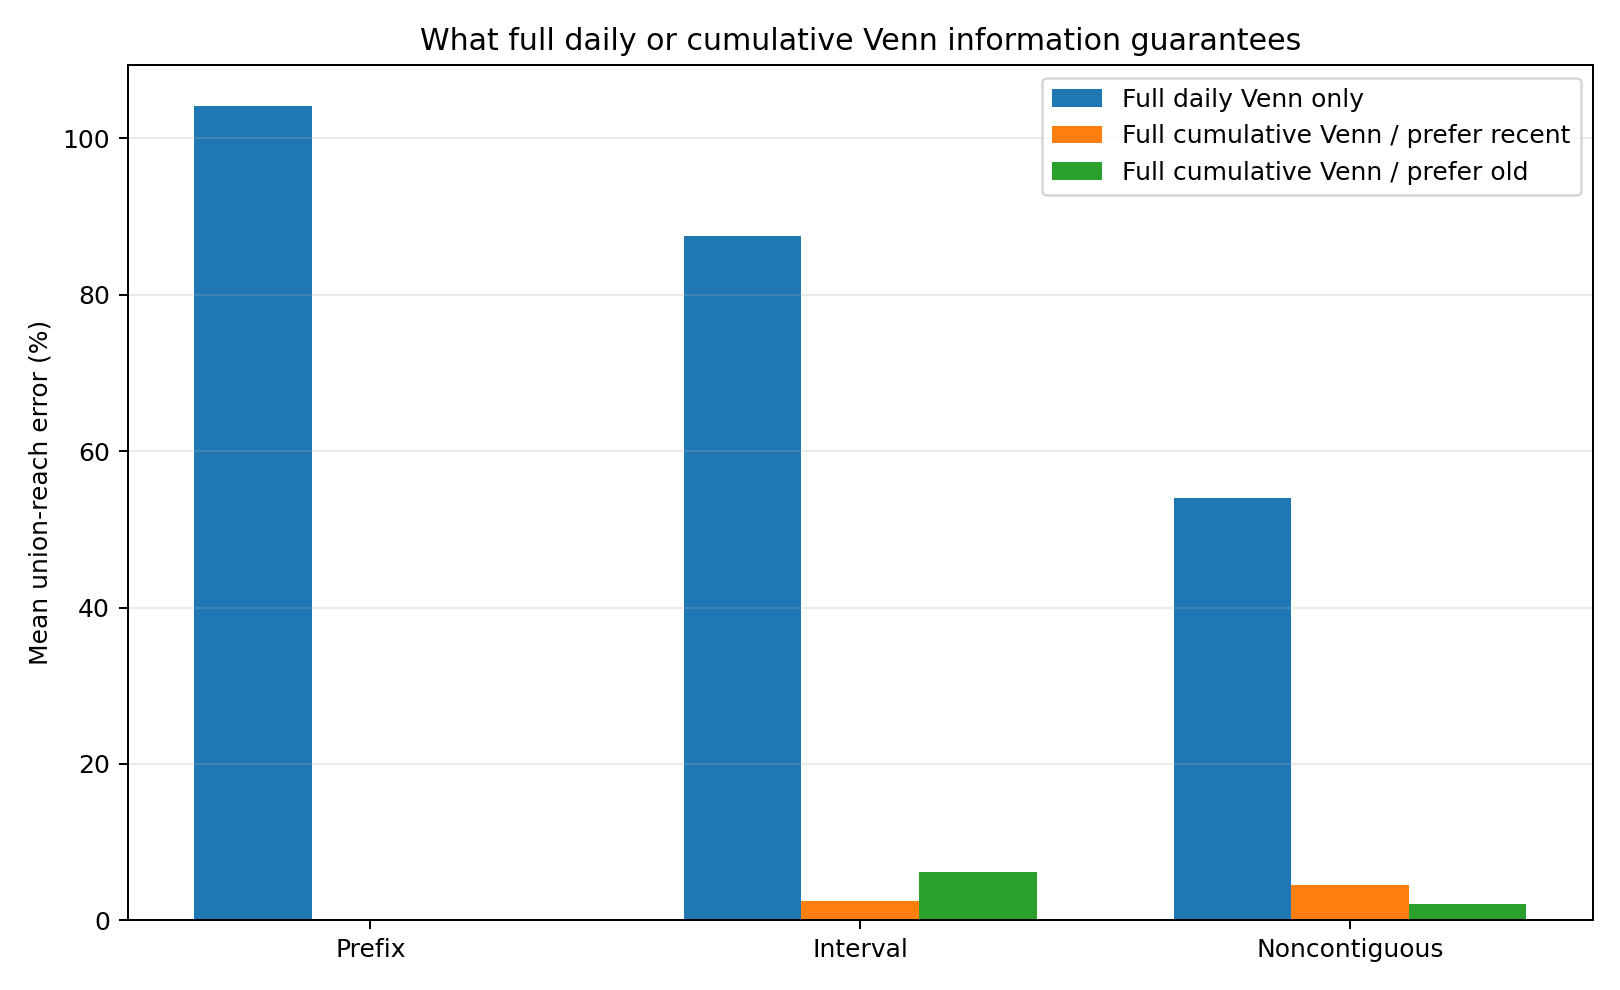

In [6]:
venn_labels = {
    "daily_full_venn": "Full daily Venn only",
    "cumulative_full_venn_recent": "Full cumulative Venn / prefer recent",
    "cumulative_full_venn_oldest": "Full cumulative Venn / prefer old",
}
rows = []
for method, label in venn_labels.items():
    result = venn_summary["methods"][method]
    rows.append({
        "method": label,
        "all": f"{result['all_reports']['mean']:.1%}",
        "prefix": f"{result['by_report_type']['prefix']['mean']:.1%}",
        "interval": f"{result['by_report_type']['interval']['mean']:.1%}",
        "noncontiguous": f"{result['by_report_type']['noncontiguous']['mean']:.1%}",
        "max": f"{result['all_reports']['max']:.1%}",
    })
display(Markdown(markdown_table(
    rows,
    [
        ("method", "Information supplied"),
        ("all", "Mean: all reports"),
        ("prefix", "Cumulative prefixes"),
        ("interval", "Middle intervals"),
        ("noncontiguous", "Noncontiguous weeks"),
        ("max", "Worst report"),
    ],
)))
print("Exact-cell audits:", venn_summary["exact_cell_audits"])
display(Image(filename=str(VENN_OUTPUT_DIR / "full_venn_report_error.png")))

The full experiment used 18,000 people, ten EDPs, thirteen weeks, nineteen campaign scenarios, and all 1,023 cumulative cells. The exact-cell audit had zero error at every cumulative checkpoint for both allocation heuristics. That simultaneously verifies all 1,023 EDP subsets at every prefix.

The remaining interval error is not a solver defect. The cumulative Venn tables specify *who has appeared by each checkpoint in aggregate*, but not which synthetic matches should be attributed to the weeks inside an arbitrary later window. Preferring recently created slots helps ordinary middle intervals; preferring old slots can help other shapes. Neither rule is universally correct.

### Why daily plus cumulative Venn is still insufficient

The limitation already exists with one EDP and three days:

| | Day 1 | Day 2 | Day 3 | Daily counts | Cumulative counts | Weeks 2–3 reach |
|---|---|---|---|---|---|---:|
| World 1 | a | b | a | 1, 1, 1 | 1, 2, 2 | 2 |
| World 2 | a | b | b | 1, 1, 1 | 1, 2, 2 | 1 |

The daily and cumulative aggregates are identical, but the middle-window answer differs. No deterministic allocator seeing only those aggregates can guarantee the right answer in both worlds. Adding all EDP Venn cells does not remove this temporal ambiguity.

### Information that is sufficient for every window

A complete activity-pattern table would classify people by every EDP × week membership bit. Given those nonnegative atom counts, create that many anonymous VIDs for each pattern and place them in every indicated EDP-week event set. Any report is then a sum of the same fixed atoms, so every EDP subset and every week subset is exact and mutually consistent.

The small proof used three EDPs and four weeks: all 105 nonempty EDP/week report combinations were exact. The cost is dimensionality. Three EDPs × four weeks allow 4,095 nonempty patterns; ten EDPs × thirteen weeks allow (2^130−1), approximately 1.36 × 10^39. Only observed patterns need storage, but obtaining the table is effectively obtaining a time-indexed identity-overlap representation. It is much stronger information than daily or cumulative Venn counts.

**Conclusion.** Complete cumulative Venn data makes cumulative reporting fully solved and makes arbitrary windows empirically very accurate, but not mathematically exact. Exact arbitrary windows require full time-pattern information, actual cross-time identity linkage, or full-flight buffering followed by one global allocation over the report calendar.

## 8. Is campaign context enough, or is observed matching necessary?

The experiment fits one predictor using objective, audience strategy, and campaign scale, and another that also sees cumulative email availability and Reference-ID matching. It then evaluates campaigns with the same sales-prospecting context but deliberately different linkage selection.

In [7]:
shift_scenarios = ["linkage_shift_-1.0", "linkage_shift_0.0", "linkage_shift_1.0"]
compare_methods = {
    "context_and_scale_only_pool": "Context + scale only",
    "sticky_first_seen_pool": "Context + cumulative matching",
    "provider_blended_ordered_pool": "Blended prior + matching",
    "ordered_collision_resolved_overlap_pool": "Encoder-specific 1:1 fit",
}
rows = []
for method, label in compare_methods.items():
    for scenario in shift_scenarios:
        values = [
            float(row["union_relative_error"])
            for row in metrics
            if row["method"] == method and row["scenario"] == scenario
        ]
        rows.append({
            "method": label,
            "shift": scenario.removeprefix("linkage_shift_"),
            "mean": f"{np.mean(values):.1%}",
        })
display(Markdown(markdown_table(
    rows,
    [("method", "Inputs used"), ("shift", "Matchability selection shift"), ("mean", "Mean union error")],
)))

| Inputs used | Matchability selection shift | Mean union error |
|---|---|---|
| Context + scale only | -1.0 | 25.0% |
| Context + scale only | 0.0 | 9.7% |
| Context + scale only | 1.0 | 16.4% |
| Context + cumulative matching | -1.0 | 27.4% |
| Context + cumulative matching | 0.0 | 9.1% |
| Context + cumulative matching | 1.0 | 16.2% |
| Blended prior + matching | -1.0 | 26.4% |
| Blended prior + matching | 0.0 | 9.3% |
| Blended prior + matching | 1.0 | 16.3% |
| Encoder-specific 1:1 fit | -1.0 | 12.6% |
| Encoder-specific 1:1 fit | 0.0 | 6.7% |
| Encoder-specific 1:1 fit | 1.0 | 9.6% |

Objective and audience strategy are useful priors, but they do not identify the realized overlap. Observed matching adds information, especially when two campaigns with similar labels select different people. It is also confounded: fewer Reference-ID matches can mean less true audience overlap, lower email availability, or both. A provider rule therefore needs both the prior and the observed signal, plus transfer validation. The measurement operator should not invent this mapping without a source of truth.

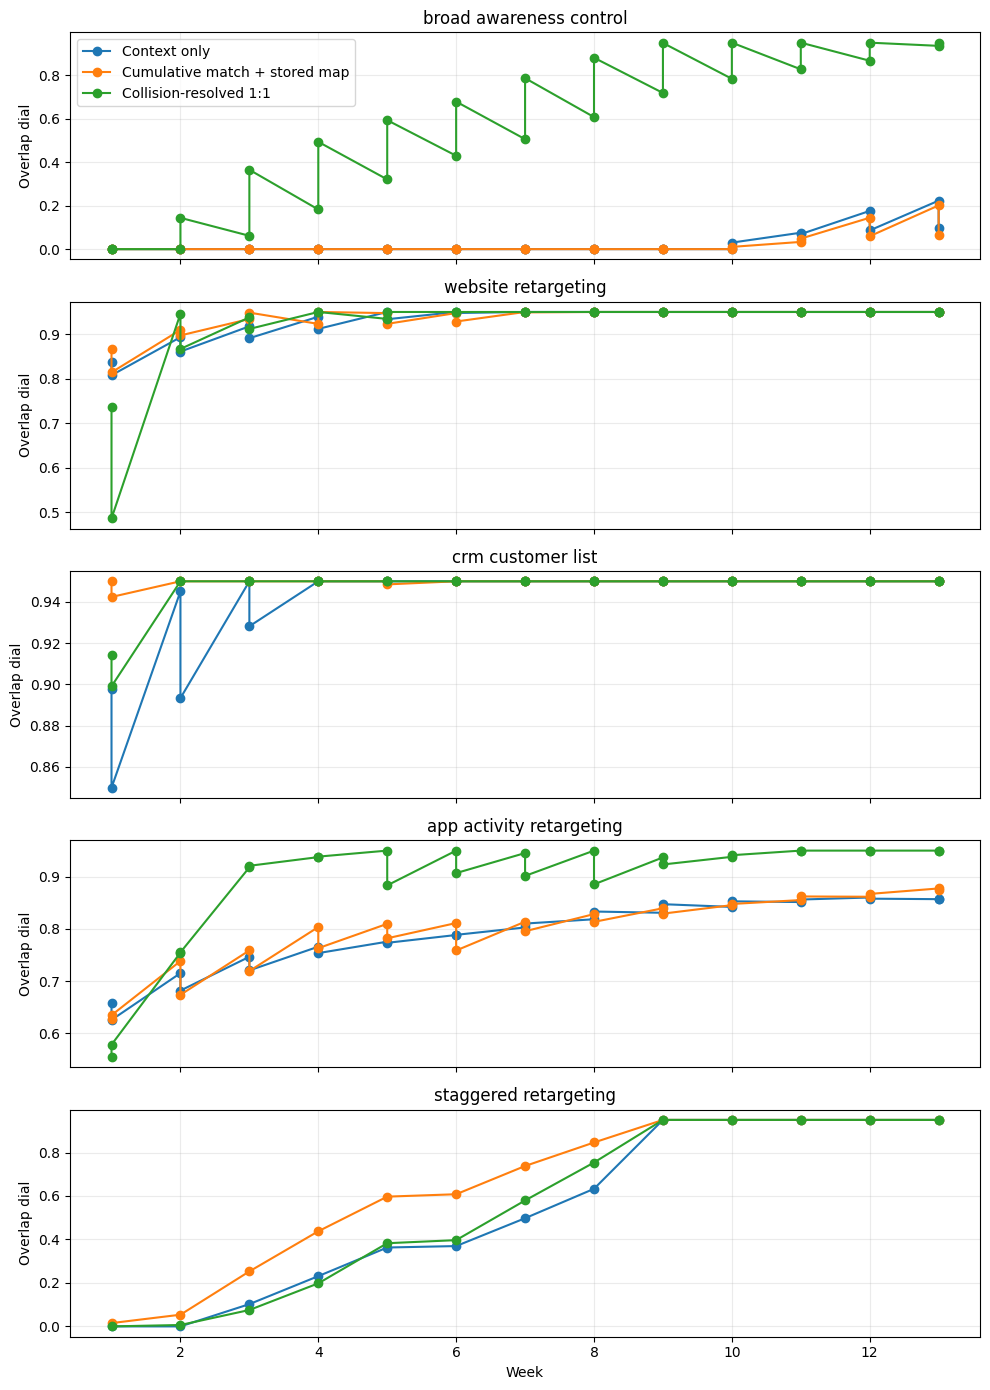

In [8]:
selected_scenarios = [
    "broad_awareness_control",
    "website_retargeting",
    "crm_customer_list",
    "app_activity_retargeting",
    "staggered_retargeting",
]
selected_methods = {
    "context_and_scale_only_pool": "Context only",
    "sticky_first_seen_pool": "Cumulative match + stored map",
    "ordered_collision_resolved_overlap_pool": "Collision-resolved 1:1",
}
fig, axes = plt.subplots(len(selected_scenarios), 1, figsize=(10, 14), sharex=True)
for axis, scenario in zip(axes, selected_scenarios):
    for method, label in selected_methods.items():
        values = sorted(
            [row for row in dials if row["scenario"] == scenario and row["method"] == method],
            key=lambda row: int(row["day"]),
        )
        if values:
            axis.plot([int(row["day"]) for row in values], [float(row["dial"]) for row in values], marker="o", label=label)
    axis.set_title(scenario.replace("_", " "))
    axis.set_ylabel("Overlap dial")
    axis.grid(alpha=.25)
axes[-1].set_xlabel("Week")
axes[0].legend(loc="best")
fig.tight_layout()
plt.show()

## 9. Cross-campaign map scope

A campaign-specific map can fit each campaign independently, but the same identifier may receive different VIDs in two campaigns. Combined campaign reach then overcounts. A model-line-wide map avoids that fragmentation, but the first campaign or context that sees an identifier influences its permanent assignment.

The experiment compares campaign-local maps, campaign-specific dials sharing one map in two processing orders, and one global daily dial shared by all campaigns. The processing-order effect is usually small for combined reach in this synthetic sample but is materially larger for some individual small campaigns. It is a real path-dependence, not a mathematical inconsistency.

In [9]:
portfolio_summary = summary["cross_campaign"]
rows = []
for method, result in portfolio_summary["methods"].items():
    rows.append({
        "method": method.replace("_", " "),
        "mean": f"{result['mean']:.1%}",
        "p90": f"{result['p90']:.1%}",
        "max": f"{result['max']:.1%}",
    })
display(Markdown(markdown_table(
    rows,
    [("method", "Map policy"), ("mean", "Mean error"), ("p90", "p90"), ("max", "Worst")],
)))
order = portfolio_summary["campaign_order_sensitivity"]
print(
    "Campaign-order sensitivity — mean: "
    f"{order['mean']:.2%}, p90: {order['p90']:.2%}, worst: {order['max']:.2%}"
)

| Map policy | Mean error | p90 | Worst |
|---|---|---|---|
| campaign local maps | 7.9% | 17.2% | 41.1% |
| shared map campaign specific forward | 9.6% | 18.2% | 86.9% |
| shared map campaign specific reverse | 9.4% | 18.3% | 81.1% |
| shared map global daily state | 11.8% | 25.8% | 119.8% |

Campaign-order sensitivity — mean: 0.27%, p90: 0.53%, worst: 5.76%


## 10. End-to-end test of the most promising design

The strongest practical experiment replaces the oracle target with the information that would actually be available in the TEE:

1. The model provider fits a frozen capture-rate model on a separate 5,000-person panel and whole-campaign training data.
2. For each cumulative checkpoint, the TEE forms one 10-bit Reference-ID membership histogram. That one histogram supplies every pairwise through ten-way aggregate without 1,023 separate joins.
3. The provider's fixed-plus-log pair model corrects the 45 pairwise overlaps. A maximum-entropy decoder turns the ten per-EDP reaches and 45 corrected pairs into one complete 1,024-cell Venn table.
4. The daily allocator projects that table onto a state reachable from the VIDs already frozen on earlier days, then assigns only newly seen identifiers.
5. Every later report is a direct distinct count over the immutable labels. No old report result is consulted.

This uses no true Venn diagram at runtime and does not link a VID to a Reference ID. Synthetic truth is retained only by the test harness for scoring.

| Method | Mean | p90 | Worst | Prefixes | Intervals | Noncontiguous |
|---|---|---|---|---|---|---|
| Existing VID | 48.0% | 132.2% | 494.6% | 53.5% | 46.2% | 35.7% |
| Provider pair calibration + reachable Venn labels | 13.6% | 31.5% | 137.6% | 14.2% | 14.6% | 10.6% |
| Direct-rate pair calibration + reachable Venn labels | 13.9% | 32.5% | 148.9% | 14.8% | 14.5% | 10.7% |

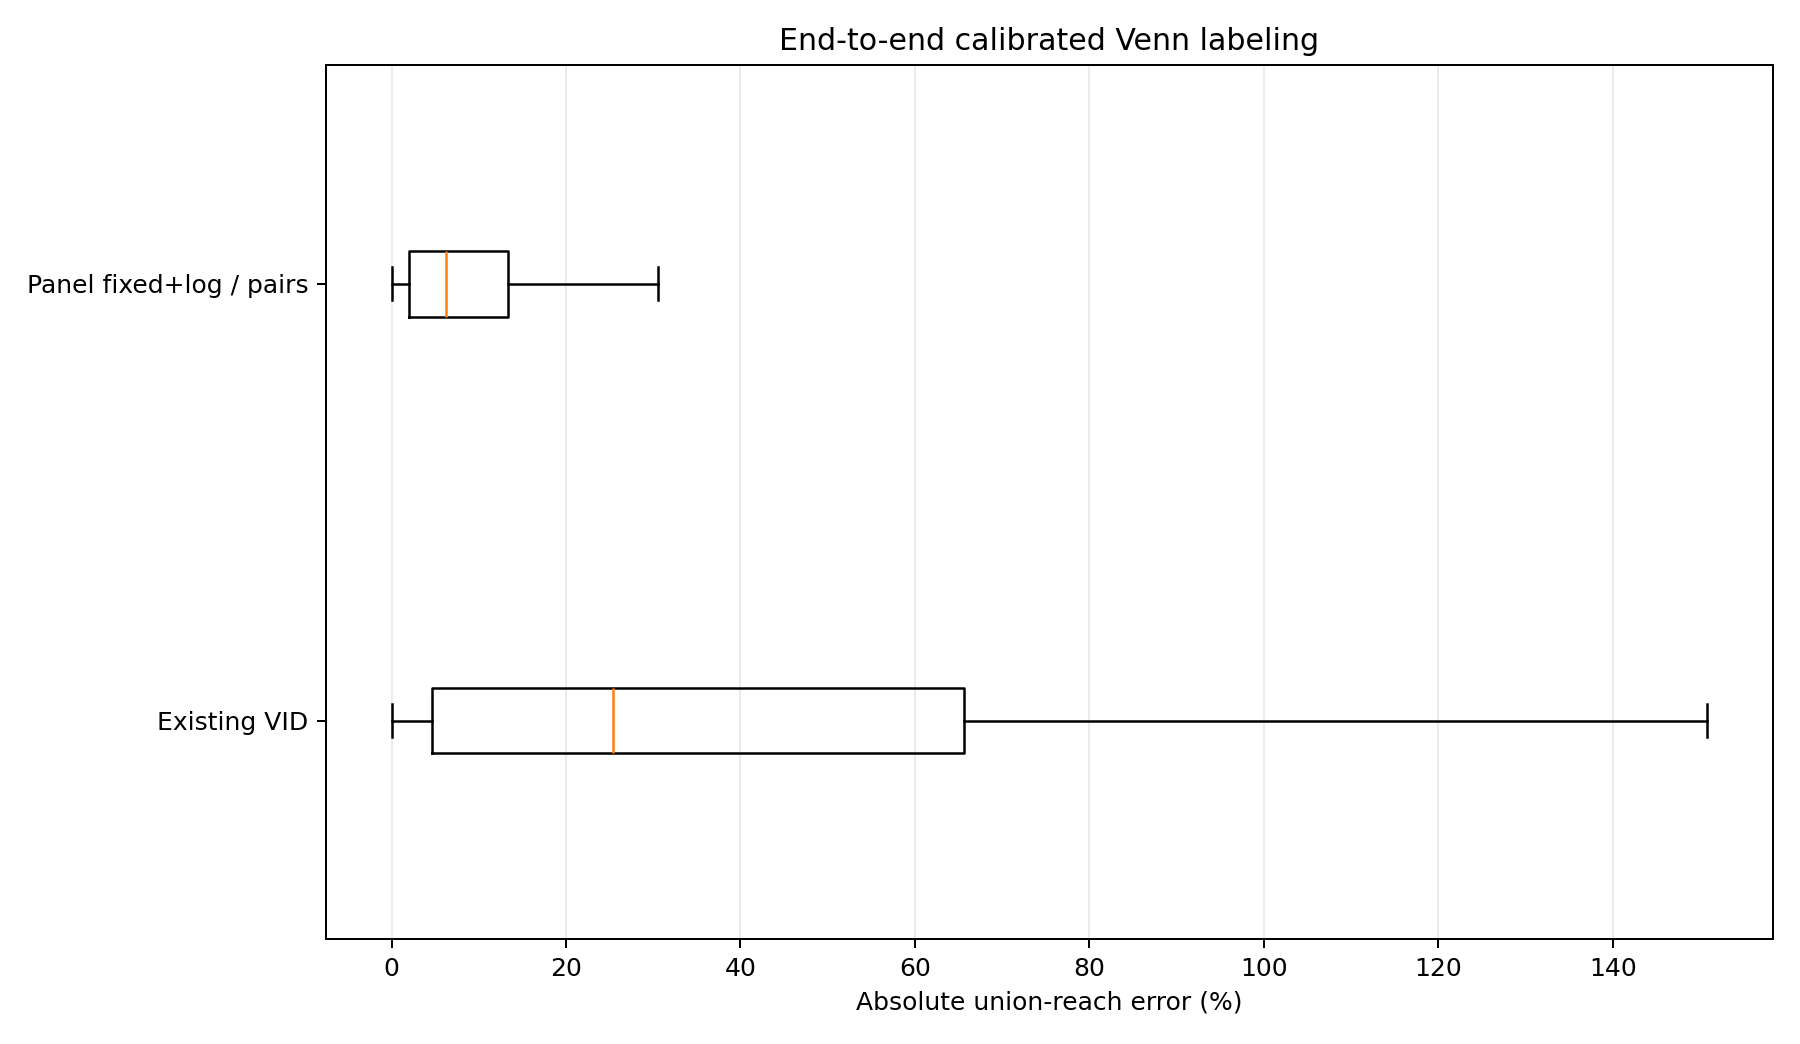

In [10]:
methods = calibrated_venn_summary["methods"]
chosen = methods["panel_fixed_log_pairwise__recent_creation"]
existing = methods["existing_vid"]
direct = direct_venn_summary["methods"]["panel_direct_pairwise__recent_creation"]
rows = [
    {
        "method": "Existing VID",
        "mean": f"{existing['report_error']['mean']:.1%}",
        "p90": f"{existing['report_error']['p90']:.1%}",
        "worst": f"{existing['report_error']['max']:.1%}",
        "prefix": f"{existing['report_error_by_type']['prefix']['mean']:.1%}",
        "interval": f"{existing['report_error_by_type']['interval']['mean']:.1%}",
        "noncontiguous": f"{existing['report_error_by_type']['noncontiguous']['mean']:.1%}",
    },
    {
        "method": "Provider pair calibration + reachable Venn labels",
        "mean": f"{chosen['report_error']['mean']:.1%}",
        "p90": f"{chosen['report_error']['p90']:.1%}",
        "worst": f"{chosen['report_error']['max']:.1%}",
        "prefix": f"{chosen['report_error_by_type']['prefix']['mean']:.1%}",
        "interval": f"{chosen['report_error_by_type']['interval']['mean']:.1%}",
        "noncontiguous": f"{chosen['report_error_by_type']['noncontiguous']['mean']:.1%}",
    },
    {
        "method": "Direct-rate pair calibration + reachable Venn labels",
        "mean": f"{direct['report_error']['mean']:.1%}",
        "p90": f"{direct['report_error']['p90']:.1%}",
        "worst": f"{direct['report_error']['max']:.1%}",
        "prefix": f"{direct['report_error_by_type']['prefix']['mean']:.1%}",
        "interval": f"{direct['report_error_by_type']['interval']['mean']:.1%}",
        "noncontiguous": f"{direct['report_error_by_type']['noncontiguous']['mean']:.1%}",
    },
]
display(Markdown(markdown_table(
    rows,
    [
        ("method", "Method"),
        ("mean", "Mean"),
        ("p90", "p90"),
        ("worst", "Worst"),
        ("prefix", "Prefixes"),
        ("interval", "Intervals"),
        ("noncontiguous", "Noncontiguous"),
    ],
)))
display(Image(filename=str(CALIBRATED_VENN_OUTPUT_DIR / "calibrated_venn_error.png")))

Across 19 independent campaigns, 13 weeks, and reports containing two, five, or ten EDPs, the end-to-end method reduced mean union-reach error from **48.0% to 13.6%**. Because the output is encoded into immutable labels, the same events always produce the same answer and every cumulative prefix is nondecreasing.

The direct bounded model, `capture = a + b × log(size)`, was also run through the complete temporal pipeline. It produced 13.9% mean error versus 13.6% for the logit model. Its median was slightly better, but its p90 and worst-case errors were slightly worse. The result supports leading with the bounded logit form while retaining the direct form as a required real-data challenger; it does not justify treating either functional form as settled.

Although the TEE can compute all 1,023 nonempty Reference-ID intersections at ten EDPs, the best synthetic result did **not** fit every order directly. In the structural comparison, pairwise calibration followed by one coherent maximum-entropy Venn performed substantially better than directly calibrating all orders or decoding every exact Reference-ID pattern. The higher-order counts remain useful for validation and residual checks; sparse high-order observations should not automatically receive their own unconstrained correction.

The result is promising but not yet a production proof. The worst campaign still had 137.6% error. The main failures were an intentionally hidden downward linkage shift, app-activity retargeting with low email matchability, and abrupt shared-seed campaigns. These are calibration-transfer failures, not inconsistencies in the final VID sets.

The daily calibrated target also moved downward at some later checkpoints. Once an earlier, larger union has been encoded, that decrease is impossible. Stronger optimizer weights cannot solve this; the reachable result must retain at least the already-created VIDs. A production rule therefore needs a conservative online policy: only activate correction in provider-validated contexts, use uncertainty to avoid early overcorrection, and retain the previous feasible target or the existing VID result when the new target moves outside its validated envelope.

In [11]:
comparison = all_models_summary["methods"]
structural_methods = [
    ("panel_fixed_log_pairwise__recent_creation", "Fixed+log pairs, inferred higher orders"),
    ("panel_mixture_pairwise__oldest_creation", "Two-group pairs, inferred higher orders"),
    ("panel_fixed_log_all_orders__oldest_creation", "Direct calibration of every order"),
    ("panel_mixture_full_patterns__oldest_creation", "Full exact-pattern mixture decoder"),
]
rows = [
    {
        "method": label,
        "mean": f"{comparison[name]['report_error']['mean']:.1%}",
        "p90": f"{comparison[name]['report_error']['p90']:.1%}",
    }
    for name, label in structural_methods
]
display(Markdown(markdown_table(
    rows,
    [("method", "Venn construction"), ("mean", "Mean report error"), ("p90", "p90")],
)))

| Venn construction | Mean report error | p90 |
|---|---|---|
| Fixed+log pairs, inferred higher orders | 13.7% | 28.3% |
| Two-group pairs, inferred higher orders | 14.4% | 38.0% |
| Direct calibration of every order | 29.9% | 84.2% |
| Full exact-pattern mixture decoder | 28.2% | 74.6% |

In [12]:
rows = []
for setting in ("5.0", "20.0", "100.0", "500.0"):
    result = regularization_summary["settings"][setting]
    rows.append({
        "setting": setting,
        "raw": f"{result['raw_error']['mean']:.1%}",
        "online": f"{result['online_monotone_error']['mean']:.1%}",
        "p90": f"{result['online_monotone_error']['p90']:.1%}",
        "drops": f"{result['downward_step_fraction']:.1%}",
    })
display(Markdown(markdown_table(
    rows,
    [
        ("setting", "Evidence half-saturation (synthetic people)"),
        ("raw", "Raw cumulative error"),
        ("online", "After immutable monotone floor"),
        ("p90", "Online p90"),
        ("drops", "Checkpoints where raw target decreased"),
    ],
)))

| Evidence half-saturation (synthetic people) | Raw cumulative error | After immutable monotone floor | Online p90 | Checkpoints where raw target decreased |
|---|---|---|---|---|
| 5.0 | 21.3% | 23.3% | 83.4% | 9.3% |
| 20.0 | 25.7% | 28.5% | 92.2% | 4.5% |
| 100.0 | 42.5% | 43.1% | 107.7% | 3.2% |
| 500.0 | 63.3% | 63.3% | 154.9% | 1.6% |

The half-saturation value controls how quickly small Reference-ID samples are trusted. A smaller value helped these synthetic non-reach campaigns, but it also produced more downward revisions. A larger value was smoother because it stayed closer to the existing VID model, but it gave back much of the accuracy improvement. This parameter should be selected on whole-campaign holdouts; there is no defensible universal value from the synthetic study alone.

In [13]:
solver_rows = []
for solver, label in (("exact_milp", "Exact integer optimizer"), ("fast_greedy", "Fast constructive allocator")):
    result = solver_summary[solver]
    solver_rows.append({
        "solver": label,
        "time": f"{result['solve_seconds']['mean']:.3f} s",
        "p90_time": f"{result['solve_seconds']['p90']:.3f} s",
        "cell_move": f"{result['cell_l1_adjustment']['mean']:.1%}",
        "error": f"{result['report_error']['mean']:.1%}",
    })
display(Markdown(markdown_table(
    solver_rows,
    [
        ("solver", "Temporal projection"),
        ("time", "Mean time/checkpoint"),
        ("p90_time", "p90 time"),
        ("cell_move", "Mean Venn-cell movement"),
        ("error", "Mean report error in solver stress set"),
    ],
)))

| Temporal projection | Mean time/checkpoint | p90 time | Mean Venn-cell movement | Mean report error in solver stress set |
|---|---|---|---|---|
| Exact integer optimizer | 4.500 s | 10.197 s | 18.8% | 15.8% |
| Fast constructive allocator | 0.057 s | 0.133 s | 31.2% | 15.8% |

At ten EDPs the exact formulation has 1,024 destination cells and 59,049 allowed old-cell-to-new-cell transitions. It averaged 4.5 seconds per daily campaign update and preserved more of the provider's detailed Venn target. The fast constructive allocator averaged 0.057 seconds—about 78 times faster. In this three-campaign stress benchmark their report errors were effectively identical: 15.79% and 15.80%. That supports the fast allocator as the primary implementation, with the exact optimizer retained as a validation oracle and fallback when the fast solution moves the requested Venn unusually far.

### 10.1 A separate online constraint: direct email anchors

The Venn allocator above deliberately tests aggregate geometry. A production labeler must also respect the fact that the same email presented at two EDPs is a direct identity anchor. That creates an additional online problem.

Consider two days. On day 1, the target asks a proprietary ID at A to share a VID with email `e` at B. On day 2, email `e` first appears at A. Keeping `e` on its stable cross-EDP VID now puts two different A identifiers on one VID, reducing A's reach. Moving `e` to another VID preserves A's reach but breaks the email anchor. With no knowledge of day 2 on day 1, no deterministic algorithm can guarantee all three properties: arbitrary overlap control, exact per-EDP reach, and permanent email anchoring.

In [14]:
global_reservation = identity_summary["reserve_every_email_vid_at_every_edp"]
future_reservation = identity_summary["future_aware_per_edp_reservation"]
separate = identity_summary["strict_email_and_proprietary_namespaces"]
rows = [
    {
        "policy": "Reserve every observed email VID at every EDP",
        "result": f"All EDPs feasible in {global_reservation['campaigns_with_all_edps_feasible']}/19 campaigns",
        "meaning": "Safe but too conservative for the broad campaign; peak proprietary demand was 3.16× remaining capacity.",
    },
    {
        "policy": "Reserve only where that email will appear later",
        "result": f"Enough per-EDP capacity in {future_reservation['campaigns_with_all_edps_feasible']}/19 campaigns",
        "meaning": "Passes a necessary capacity check, not a full allocation proof, and requires future identity-roster knowledge unavailable to a strict same-day algorithm.",
    },
    {
        "policy": "Never overlap email and proprietary VID namespaces",
        "result": f"Misses a mean {separate['mean_true_pair_overlap_that_crosses_identifier_modes']:.1%} of true pair overlap",
        "meaning": "Operationally simple, but discards too much legitimate email-to-proprietary overlap.",
    },
]
display(Markdown(markdown_table(
    rows,
    [("policy", "Policy"), ("result", "Synthetic result"), ("meaning", "Interpretation")],
)))

| Policy | Synthetic result | Interpretation |
|---|---|---|
| Reserve every observed email VID at every EDP | All EDPs feasible in 18/19 campaigns | Safe but too conservative for the broad campaign; peak proprietary demand was 3.16× remaining capacity. |
| Reserve only where that email will appear later | Enough per-EDP capacity in 19/19 campaigns | Passes a necessary capacity check, not a full allocation proof, and requires future identity-roster knowledge unavailable to a strict same-day algorithm. |
| Never overlap email and proprietary VID namespaces | Misses a mean 44.0% of true pair overlap | Operationally simple, but discards too much legitimate email-to-proprietary overlap. |

This narrows the recommendation. A label-time design can encode a provider-estimated full cumulative Venn and make all future reports logically consistent. To preserve direct email semantics as well, it also needs one of the following: an EDP/model-line identity roster that allows safe reservation before campaign delivery, a bounded finalization buffer with enough lookahead, or an explicit rule allowing a small number of anchor misses. Merely increasing the VID space does not remove the conflict; the issue is local slot occupancy at the EDP where the email arrives later.

### 10.2 What the current ranked serving path contributes

The current `RankedPopulationNode` already provides two valuable pieces: a collision-free Feistel assignment for pre-ranked identifiers and a two-pass mode that identifies the selected pool before final labeling. It does not by itself coordinate ranks across EDPs or reserve a future shared-email slot. The smallest credible extension is therefore a model-line-wide coordinated rank service inside the TEE, not a new static hash formula:

- retain the existing EDP-local fingerprint-to-rank indexes;
- add a durable VID-slot ledger recording the EDP membership of each occupied slot;
- apply the provider's Venn target as quotas for allowed slot transitions;
- reserve or otherwise protect direct-email assignments; and
- emit ordinary immutable VIDs after the daily state is committed.

The provider need not supply the true Venn. It supplies the frozen rule that translates cumulative VID reaches and Reference-ID overlaps into the target Venn. The measurement operator applies that rule and the reachability constraints inside the TEE.

## 11. Recommended research architecture

The best next implementation is not a freely changing daily Dirac mixture. It is an **ordered memoized overlap allocator**:

1. Maintain one canonical identifier-to-VID assignment for the model line. Previously seen identifiers always reuse it.
2. Compute both daily and cumulative Reference-ID match summaries inside the TEE, but use the cumulative value as the primary signal. Daily values are diagnostics or a bounded fast-response term.
3. Have the model provider supply and version the function that converts campaign context, scale, model-line coverage assumptions, and aggregate Reference-ID overlaps into target pairwise and selected higher-order overlaps. The runtime does not need to reveal whether any one Reference ID came from email or fallback.
4. Hold each EDP's pool size fixed and adjust only overlap among the EDP pools. Preserve direct shared-email anchors, then jointly allocate only newly seen proprietary fallback identifiers into private, pair, and structured higher-order shared slots. This step requires an explicit reservation, lookahead, or anchor-exception policy; the aggregate Venn target alone is insufficient. Do not let a smaller hash pool manufacture overlap through same-EDP collisions.
5. Freeze one daily allocation manifest after an event-time watermark. Late data uses that manifest. Never relabel a prior impression.
6. Make the calibration state model-line-wide. Campaign-specific features may influence target quotas, but the canonical assignment cannot fork by campaign without harming combined-campaign reach.
7. Validate prefix, interval, noncontiguous, subset, and cross-campaign reports separately. Zero consistency violations is necessary but not an accuracy metric.

The current simulation establishes that the aggregate Venn-to-label step is computationally feasible and materially more accurate than the existing VID baseline in the tested non-representative campaigns. It does **not** yet establish a production-safe online email-reservation policy or acceptable error under hidden linkage shifts. Those are the two gating questions for a real-data prototype.

## 12. Other designs worth considering

- **Provider-defined low-rank pool basis.** Learn a small set of reusable EDP membership patterns from calibration campaigns, then allocate new IDs only among those patterns. This is more interpretable than 1,023 independent ten-EDP cells and more expressive than one global lane.
- **Three-state reservation lattice.** Track each VID slot at each EDP as occupied, open, or reserved for a direct identifier that may arrive later. At ten EDPs this has at most `3^10 = 59,049` aggregate state classes—the same scale as the exact transition graph—but it requires a trustworthy way to set future reservations.
- **Several deterministic candidate VIDs per identifier.** Cuckoo-hashing-style choices can lower the chance that a future email anchor finds its preferred VID occupied. They provide a probabilistic safety valve, not a guarantee, and unrelated identifiers need coordinated shared candidates if they are to create useful synthetic overlap.
- **Model-line anchor registry.** Pre-register stable email-to-VID assignments and EDP-specific eligibility before campaign labeling, then let proprietary identifiers use only safe positions. This most closely preserves current VID semantics, but it needs broader identity-roster input than campaign-to-date aggregates alone.
- **Arrival-aware allocation cost.** Prefer synthetic matches with compatible first-seen weeks and activity histories. The oracle “recent” and “oldest” results show that timing policy matters, but a fixed recency rule is not universally best.
- **Coordinated-sampling pools.** Use shared random priorities so EDPs choose aligned samples or ranks without exchanging raw identifiers. This can estimate and construct overlap with less state, although it still cannot discover unmatched real identities.
- **Multi-resolution VID ladder.** Store several deterministic candidate labels per event and freeze one resolution for the model line or flight. This avoids rereading raw events but requires a measurement-protocol change and does not permit reports to choose different resolutions independently.
- **Forward-only VID aliases.** Keep base VIDs immutable and allow the TEE to merge aliases later. This is operationally tempting but changes old report results unless alias versions are frozen; it is calibration after labeling in another form.
- **Flight buffer.** Buffer the first few days, estimate a flight setting, then label the buffer and future days once. It is simple and stable but creates explicit reporting latency.
- **Full arrival-pattern pools.** Index pools by EDP membership and first-reach time. This can make arbitrary windows exact in principle, but the state grows combinatorially and requires information that is generally not available when the first event is labeled.

## 13. What to validate with real data

Before changing the serving model, the provider should replay real panel-labeled campaigns through the proposed ordered allocator and hold out entire campaigns. At minimum, measure:

- total and per-EDP reach error;
- pairwise through at least four-way intersection error;
- two-, five-, and ten-EDP union error;
- cumulative prefixes, middle intervals, noncontiguous weeks, and early-then-later reruns;
- campaigns with the same objective but different observed matchability;
- small retargeting against large reach, and two small correlated campaigns;
- cross-campaign reports under different ingestion orders;
- pool saturation, fallback rate, state size, late-data behavior, and sensitivity to the daily watermark.

The provider should compare the best label-time allocator with both the current VID model and post-measurement Reference-ID correction. Label-time calibration is preferable only if it preserves VID semantics **and** gives a competitive accuracy bound over the report shapes the product supports.

## 14. What a 5,000-person panel can and cannot establish

The runtime Reference-ID counts can be large even when the provider panel is small. The panel is still needed to learn whether those observed matches correspond to true overlap. A 5,000-person panel becomes weak quickly for small daily audiences and higher-order intersections.

The table below is the idealized 95% relative sampling-error half-width for a simple proportion. Real effective sample size may be lower, and an intersection is often much smaller than the campaign reach itself.

In [15]:
panel_size = 5_000
rows = []
for fraction in (0.001, 0.0025, 0.005, 0.01, 0.02, 0.05, 0.10, 0.25, 0.50):
    expected = panel_size * fraction
    relative_half_width = 1.96 * np.sqrt(fraction * (1 - fraction) / panel_size) / fraction
    rows.append({
        "fraction": f"{fraction:.2%}",
        "expected": f"{expected:.1f}",
        "relative": f"{relative_half_width:.1%}",
    })
display(Markdown(markdown_table(
    rows,
    [
        ("fraction", "Population fraction"),
        ("expected", "Expected panel members"),
        ("relative", "Approx. 95% relative half-width"),
    ],
)))

| Population fraction | Expected panel members | Approx. 95% relative half-width |
|---|---|---|
| 0.10% | 5.0 | 87.6% |
| 0.25% | 12.5 | 55.4% |
| 0.50% | 25.0 | 39.1% |
| 1.00% | 50.0 | 27.6% |
| 2.00% | 100.0 | 19.4% |
| 5.00% | 250.0 | 12.1% |
| 10.00% | 500.0 | 8.3% |
| 25.00% | 1250.0 | 4.8% |
| 50.00% | 2500.0 | 2.8% |

This argues against fitting a free calibration independently for every day, campaign, EDP pair, and higher-order subset. The provider should pool information across many campaigns, use the daily Reference-ID measurement as a high-volume runtime signal, and keep the response model low-dimensional. Small-day estimates should shrink toward campaign-to-date and model-line priors.

## 15. Research and implementation references

- *Virtual People: Actionable Reach Modeling* — establishes why per-event VID assignment gives an internally consistent reach set function and describes deterministic Dirac-mixture assignment.
- *Cross-Media Measurement with Virtual People* — uses daily panel weights and affinity hashing to minimize assignment changes when weights vary; this motivates consistent, but not necessarily immutable, daily routing.
- WFA `virtual-people-core-serving` — `PopulationNodeImpl`, `BranchNodeImpl`, `DistributedConsistentHashing`, `RankedPopulationNodeImpl`, and `VidModelSelector` define the current serving primitives.
- WFA `cross-media-measurement` memoized VID pipeline — Phase 0 pool identification, Phase 1 persistent ranking, and Phase 2 labeling provide the closest existing execution shape.
- Lamping and Veach, *A Fast, Minimal Memory, Consistent Hash Algorithm* — minimal-remapping hash assignment when bucket counts change.
- Ioffe, *Improved Consistent Sampling, Weighted Minhash and L1 Sketching* — coordinated weighted sampling under changing weights.
- Cohen and Kaplan, *Coordinated Weighted Sampling for Estimating Aggregates over Multiple Weight Assignments* — shared random priorities for comparable summaries over related populations and time periods.
- Griffeath, *A Maximal Coupling for Markov Chains* — formalizes the general idea of changing a joint assignment while leaving each marginal distribution unchanged.
- Gandhi, Khuller, Parthasarathy, and Srinivasan, *Dependent Rounding in Bipartite Graphs* — useful algorithmic precedent for turning fractional sharing targets into discrete assignments while preserving marginal totals.
- Pass, *Multi-marginal Optimal Transport: Theory and Applications* — the many-EDP version can be viewed as choosing one joint allocation with fixed EDP marginals and a cost for missing desired pair and higher-order overlaps.
- Capture–recapture latent-mixture literature — motivates person-level matchability classes and warns that heterogeneous capture probabilities cannot be recovered from one average rate alone.